In [1]:
from IPython.display import display, clear_output
import os
import sourcedefender
import numpy as np
import torch
import sys
import argparse
import time
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split, dataset, Subset
import pandas as pd
import argparse
from mpl_toolkits.mplot3d import Axes3D
import gc

sys.path.append("../../../")
sys.path.append("../")
sys.path.append("./")

from lib.batchJacobian import batchJacobian_PDE
from lib.util import MHPI, UnitGaussianNormalizer
from lib.utilities3 import prepare_dataset, upscale_tensor, calculate_errors, check_if_from_ddp, adjust_state_dict, plot_log_loss, NonLocalMeansSmoothing, calculate_relative_errors
from lib.utiltools import loss_live_plot, GaussianRandomFieldGenerator, generate_batch_parameters, AutomaticWeightedLoss
from lib.DerivativeComputer import batchJacobian_AD_Dist
from lib.hellper import *
from lib.helper import LargeHydrologyDataset
from lib.helper import get_checkpoint_path, plot_ever_inundation_confusion


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}\n')

# Dataset and case configuration
SAVED_MODEL_PATH = '../../../experiments/dam_break/saved_models'
# This creates a 'pointer' to the data on disk without filling up your RAM
case = 'dam_break'
operator_type = 'FNO'


Device: cuda:0



# Loading Dataset

In [7]:
eval_size = 150
batch_size = 2
T_Total = 49

T_in = 1
T_out = T_Total - T_in

Nx = 164 * 2
Ny = 164

train_size = 300
tag_mag = 'test_mag_residual_model5_Deeper2_3'

In [8]:
# --- 1. Load Magnifier Model ---

path_mag, mode_mag = get_checkpoint_path(
    case, Nx, Ny, T_in, T_out, 
    tag=tag_mag, 
    op_type=operator_type, 
    train_size=train_size, 
    ig_enabled=False,
    SAVED_MODEL_PATH = SAVED_MODEL_PATH
)

checkpoint_mag = torch.load(path_mag, map_location=device, weights_only=False)
# plot_log_loss(checkpoint_mag["loss_df_magnifier"], mode=mode_mag + '_Magnifier_Model' + f' (Epoch: {checkpoint_mag["epoch"]})', plot_ig_loss=False)

plot_log_loss(checkpoint_mag["loss_df_main"], mode=mode_mag + '_Global_Model' + f'  (Epoch: {checkpoint_mag["epoch"]})', plot_ig_loss=False)

loading dataset

In [9]:
DATASET_PATH = checkpoint_mag['config_arg']['paths']['main_path']

topo_path = os.path.join(DATASET_PATH, checkpoint_mag['config_arg']['paths']['topo_file'])
a_path = os.path.join(DATASET_PATH, checkpoint_mag['config_arg']['paths']['input_file'])
u_path = os.path.join(DATASET_PATH, checkpoint_mag['config_arg']['paths']['solution_file'])

# full_dataset = LargeHydrologyDataset(a_path, u_path)
full_dataset = LargeHydrologyDataset(a_path, u_path, mask=True, csv_path='/storage/work/amb10399/project/MHPI_FLOOD/Hurricane_Matthew_Flood/data/dam_break/DEM_data/dam_up.csv', Lx=26460.0, Ly=20940.0)

# 2. Split with a fixed generator for reproducibility
n = len(full_dataset)

# Make deterministic indices
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=g).tolist()
test_idx  = perm[train_size + eval_size:]
test_dataset = Subset(full_dataset, test_idx)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Loading Trained Models

In [10]:
from models.fno3d_encoder import FNO3d
from models.magnifier5 import FiLMLightMagnifier as magnifier

# --- 1. Load Global Model ---
model_global = FNO3d(
    T_in=T_in, T_out=48,
    modes_x=checkpoint_mag['config']['Mode1_G'], 
    modes_y=checkpoint_mag['config']['Mode2_G'], 
    modes_t=checkpoint_mag['config']['Mode3_G'],
    width=checkpoint_mag['config']['width_FNO'],
    
    encoder_kernel_size_x=82,
    encoder_kernel_size_y=41,
    encoder_num_layers=4
)

is_DDP_glb = check_if_from_ddp(checkpoint_mag)
  
if is_DDP_glb:   
    adjusted_state_dict = adjust_state_dict(checkpoint_mag['model_state_dict'], model_global)
    model_global.load_state_dict(adjusted_state_dict)
else:
    model_global.load_state_dict(checkpoint_mag['model_state_dict'])

model_global = model_global.to(device)


# --- 2. Load Magnifier Model ---
model_magnifier = magnifier(width=64).to(device)

is_DDP_mag = check_if_from_ddp(checkpoint_mag)

state_dict_mag = checkpoint_mag['magnifier_state_dict'] 

if is_DDP_mag:   
    state_dict_mag = adjust_state_dict(state_dict_mag, model_magnifier)

model_magnifier.load_state_dict(state_dict_mag)


<All keys matched successfully>

# Generate coarse-resolution depth predictions using the trained global model.

In [11]:
import time
import torch
from tqdm import tqdm
from lib.helper import coarsen_spatial_tensor

model_global.eval()

# ---- user control ----
MAX_SAMPLES = 50   # <- set this to how many samples you want

# ---- load topo once ----
topo = torch.load(topo_path, map_location="cpu").to(device)

# ---- CPU buffers ----
forcing_all = torch.empty(0, device="cpu")
u0_all      = torch.empty(0, device="cpu")
u_true_all  = torch.empty(0, device="cpu")
u_pred_coarse_all  = torch.empty(0, device="cpu")

t_start = time.time()
num_collected = 0

with torch.no_grad():
    for _, batch_data in tqdm(enumerate(test_loader, 1), total=len(test_loader),
                              desc="Processing batches"):

        batch_data = [item.to(device, non_blocking=True) for item in batch_data]
        batch_forcing = batch_data[0][..., ::2]
        batch_sol     = batch_data[1][..., ::2]

        # batch_u0    = torch.ones_like(batch_sol[..., :T_in])
        batch_u0    = batch_sol[..., :T_in]

        batch_u_out = batch_sol[..., T_in:]

        bs = batch_u0.shape[0]

        # ---- trim batch if it would exceed MAX_SAMPLES ----
        remaining = MAX_SAMPLES - num_collected
        if remaining <= 0:
            break
        if bs > remaining:
            batch_forcing = batch_forcing[:remaining]
            batch_u0      = batch_u0[:remaining]
            batch_u_out   = batch_u_out[:remaining]
            bs = remaining

        batch_topo = topo.expand(bs, -1, -1)

        U_pred_batch = model_global(batch_forcing, batch_u0, batch_topo)

        # ---- move to CPU ----
        forcing_all = torch.cat((forcing_all, batch_forcing.cpu()), dim=0)
        u0_all      = torch.cat((u0_all, batch_u0.cpu()), dim=0)
        u_true_all  = torch.cat((u_true_all, batch_u_out.cpu()), dim=0)
        u_pred_coarse_all  = torch.cat((u_pred_coarse_all, U_pred_batch.cpu()), dim=0)

        num_collected += bs

        del batch_forcing, batch_sol, batch_u0, batch_u_out, batch_topo, U_pred_batch
        
u_pred_coarse_all[u_pred_coarse_all<0.025] = 0.0
u_true_all[u_true_all<0.025] = 0.0

t_end = time.time()
print(
    f"Processed {num_collected} samples in {t_end - t_start:.2f}s "
    f"({(t_end - t_start)/max(num_collected,1):.3f} s/sample)"
)

u_true_all_coarse = coarsen_spatial_tensor(u_true_all, N=4,  mode='area')


Processing batches:   9%|▉         | 25/275 [00:03<00:30,  8.32it/s]


Processed 50 samples in 3.06s (0.061 s/sample)


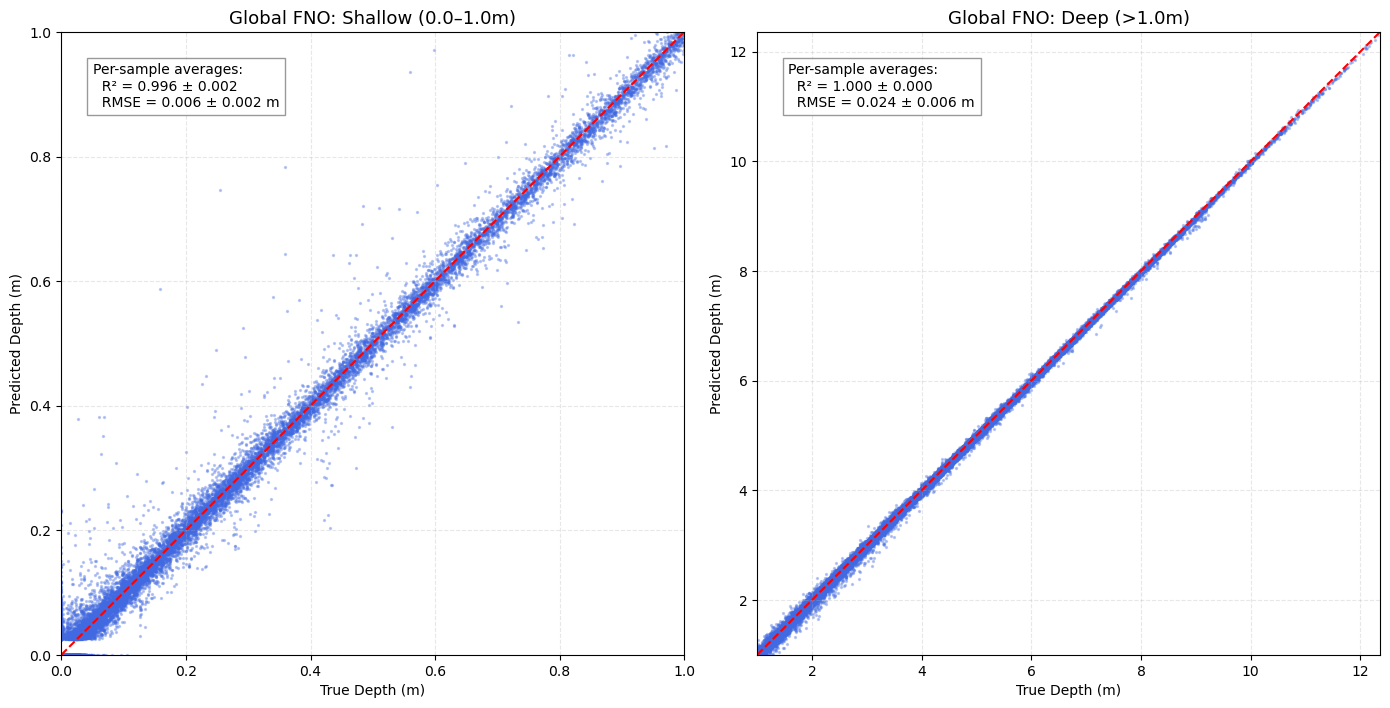

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ─── Data Setup: Focus on Coarse Row Only ────────────────────────────────────
# u_true_all_coarse: Ground Truth after 'area' coarsening
# u_pred_coarse_all: Raw FNO output before upscaling
u_true_c = u_true_all_coarse.detach().cpu().numpy()
u_pred_c = u_pred_coarse_all.detach().cpu().numpy()

# Dataset list reduced to just the Coarse Global Model
datasets = [(u_true_c, u_pred_c, "Global FNO (Coarse)")]

# Define depth ranges (m)
depth_ranges = [
    (0.0, 1.0, "Shallow (0.0–1.0m)"),
    (1.0, u_true_c.max(), "Deep (>1.0m)")
]

# Create 1 row x 2 cols plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Since there's only one row, axes will be a 1D array
for col_idx, (dmin, dmax, range_title) in enumerate(depth_ranges):
    ax = axes[col_idx]
    
    r2_list, rmse_list = [], []
    scatter_x, scatter_y = [], []
    
    for i in range(u_true_c.shape[0]):
        true_flat = u_true_c[i].ravel()
        pred_flat = u_pred_c[i].ravel()
        
        # Apply depth mask
        mask = (true_flat >= dmin) & (true_flat < dmax)
        if np.sum(mask) < 50: continue
            
        x_s, y_s = true_flat[mask], pred_flat[mask]
        
        r2_list.append(r2_score(x_s, y_s))
        rmse_list.append(np.sqrt(mean_squared_error(x_s, y_s)))
        
        # Subsampling for performance
        if len(x_s) > 5000:
            sel = np.random.choice(len(x_s), 5000, replace=False)
            scatter_x.extend(x_s[sel]); scatter_y.extend(y_s[sel])
        else:
            scatter_x.extend(x_s); scatter_y.extend(y_s)
    
    # Plotting
    ax.scatter(scatter_x, scatter_y, s=2, alpha=0.3, color='royalblue', rasterized=True)
    limit_max = dmax if np.isfinite(dmax) else max(scatter_x)
    ax.plot([dmin, limit_max], [dmin, limit_max], 'r--', lw=1.5, label='Ideal')
    
    ax.set_xlim(dmin, limit_max); ax.set_ylim(dmin, limit_max)
    ax.set_aspect('equal')
    
    metrics_text = (
        f"Per-sample averages:\n"
        f"  R² = {np.mean(r2_list):.3f} ± {np.std(r2_list):.3f}\n"
        f"  RMSE = {np.mean(rmse_list):.3f} ± {np.std(rmse_list):.3f} m"
    )
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    ax.set_title(f"Global FNO: {range_title}", fontsize=13)
    ax.set_xlabel("True Depth (m)"); ax.set_ylabel("Predicted Depth (m)")
    ax.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

Plot inundation confusion


Confusion counts (sample=20, th=0.025 m)
----------------------------------------
TP (Correct wet)      : 691  ( 20.55%)
TN (Correct dry)      : 2,618  ( 77.87%)
FP (False alarm wet)  : 53  (  1.58%)
FN (Missed wet)       : 0  (  0.00%)
Total pixels counted  : 3,362  (100.00%)

Confusion matrix [[TN, FP],[FN, TP]]:
[[2618   53]
 [   0  691]]

Accuracy              : 0.9842
Wet Precision (PPV)   : 0.9288
Wet Recall (TPR/POD)  : 1.0000
F1 (wet)              : 0.9631


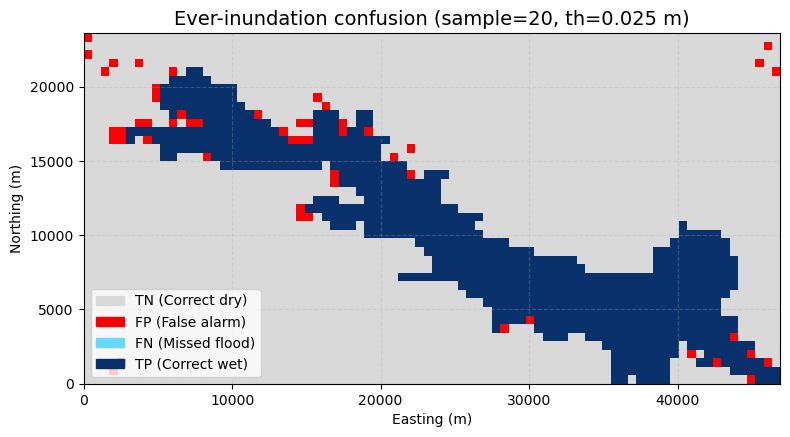


Confusion counts (ALL samples + pixels, th=0.025 m)
---------------------------------------------------
TP (Correct wet)      : 35,521  ( 21.13%)
TN (Correct dry)      : 124,999  ( 74.36%)
FP (False alarm wet)  : 7,555  (  4.49%)
FN (Missed wet)       : 25  (  0.01%)
Total pixels counted  : 168,100  (100.00%)

Confusion matrix [[TN, FP],[FN, TP]]:
[[124999   7555]
 [    25  35521]]

Accuracy              : 0.9549
Wet Precision (PPV)   : 0.8246
Wet Recall (TPR/POD)  : 0.9993
F1 (wet)              : 0.9036


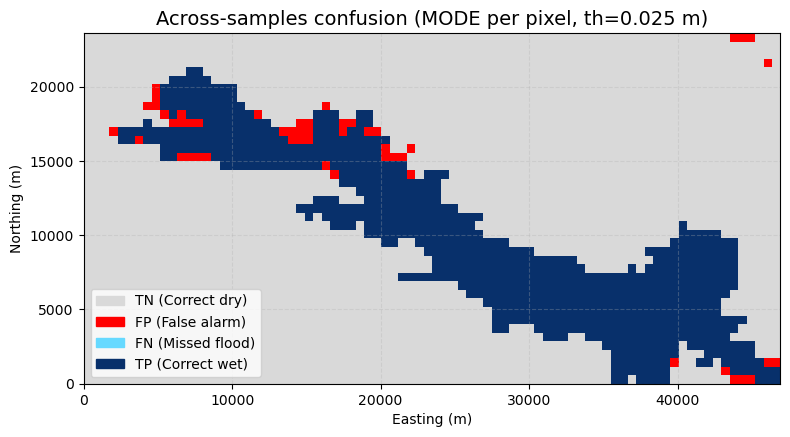

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches



extent = [0, 248417.934 - 201527.934, 0, 3922540.192 - 3898940.192]
plot_ever_inundation_confusion(u_true_all_coarse, u_pred_coarse_all, sample_idx=20, inund_th=0.025, extent=extent)
plot_ever_inundation_confusion(u_true_all_coarse, u_pred_coarse_all, sample_idx=None, inund_th=0.025, extent=extent)


In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from datetime import datetime, timedelta
import numpy as np

# ==========================================
# 1) Data Selection & Error Calculation (Coarse Only)
# ==========================================
sample_idx = 20 

# Extract Coarse Data [nx_c, ny_c, nt]
# Using the ::4 stride to match your temporal subsetting
u_true_c = u_true_all_coarse[..., ::4][sample_idx].detach().cpu().numpy()
u_pred_c = u_pred_coarse_all[..., ::4][sample_idx].detach().cpu().numpy()
u_err_c  = np.abs(u_true_c - u_pred_c)

num_frames = u_true_c.shape[-1]

# ==========================================
# 2) Coordinate & Color Configuration
# ==========================================
start_date = datetime(2016, 10, 5, 12, 0, 0)
time_step_seconds = 3600
time_dates = [start_date + timedelta(seconds=i * time_step_seconds) for i in range(num_frames)]

# Color scales
vmin, vmax = 0.0, u_true_c.max() * 0.8
err_vmin, err_vmax = 0.0, 0.2  # Fixed scale for identifying spatial error clusters

# Physical extent logic for PSU state college area data
X_range = 248417.934 - 201527.934
Y_range = 3922540.192 - 3898940.192
extent = [0, X_range, 0, Y_range]

# ==========================================
# 3) Figure Setup: 1 Row x 3 Columns
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

titles = ["True (Coarse)", "Pred (Coarse)", "Abs Error (Coarse)"]
ims = [None] * 3

# Initialize images
# .T aligns [nx, ny] with imshow's [y, x] requirement
ims[0] = axes[0].imshow(u_true_c[:, :, 0].T, extent=extent, origin="lower", cmap="terrain", vmin=vmin, vmax=vmax)
ims[1] = axes[1].imshow(u_pred_c[:, :, 0].T, extent=extent, origin="lower", cmap="terrain", vmin=vmin, vmax=vmax)
ims[2] = axes[2].imshow(u_err_c[:, :, 0].T,  extent=extent, origin="lower", cmap="magma", vmin=err_vmin, vmax=err_vmax)

for i in range(3):
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].grid(True, linestyle="--", alpha=0.3)
    axes[i].set_xlabel("Easting (m)")

axes[0].set_ylabel("Northing (m)")

# Add colorbars
cbar_ax1 = fig.add_axes([0.15, 0.08, 0.35, 0.03])
fig.colorbar(ims[0], cax=cbar_ax1, label="Water Depth (m)", orientation="horizontal")

cbar_ax2 = fig.add_axes([0.65, 0.08, 0.20, 0.03])
fig.colorbar(ims[2], cax=cbar_ax2, label="Abs Error (m)", orientation="horizontal")

plt.subplots_adjust(bottom=0.22, wspace=0.15)

# ==========================================
# 4) Update Function
# ==========================================
def update(f_idx):
    current_dt = time_dates[f_idx]
    fig.suptitle(
        f"Global FNO Dynamics: Sample {sample_idx}\nTime: {current_dt.strftime('%Y-%m-%d %H:%M')}",
        fontsize=16, fontweight="bold"
    )
    
    ims[0].set_data(u_true_c[:, :, f_idx].T)
    ims[1].set_data(u_pred_c[:, :, f_idx].T)
    ims[2].set_data(u_err_c[:, :, f_idx].T)

    return ims

# ==========================================
# 5) Generate Animation
# ==========================================
ani = animation.FuncAnimation(fig, update, frames=range(num_frames), interval=200, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())

# Apply the trained Magnifier for topography-aware upscaling.

In [ ]:
from lib.helper import prepare_patch_input, BathtubReconstructor
import torch
import torch.nn.functional as F

model_magnifier.eval()

# ---- Configuration from Checkpoints ----
N = checkpoint_mag['config']['N_window']       # e.g., 5
f = checkpoint_mag['config']['f_upscale']      # e.g., 10
T_out = checkpoint_mag['config']['T_out']
DRY_THRESHOLD = 0.025 

# Global dimensions
num_samples, mx, my, _ = u_pred_coarse_all.shape
nx_fine, ny_fine = mx * f, my * f

# ---- Initialize Reconstructor for Inference ----
# topo should be the full high-res topography [nx_fine, ny_fine]
reconstructor = BathtubReconstructor(topo, f=f, max_iters=20).to(device)

# ---- Buffers ----
u_upscaled_acc = torch.zeros((num_samples, nx_fine, ny_fine, T_out), device="cpu")
u_upscaled_cnt = torch.zeros((num_samples, nx_fine, ny_fine, T_out), device="cpu")

# ---- Global Normalization Constants ----
GLOBAL_TOPO_MIN = topo.min()
GLOBAL_TOPO_MAX = topo.max()
TOPO_RANGE = (GLOBAL_TOPO_MAX - GLOBAL_TOPO_MIN) + 1e-7

# ---- 1. Generate Global Bathtub Reconstruction ----
print("Generating Global Bathtub Baseline...")
with torch.no_grad():
    # Move u_pred_coarse_all to device for the reconstructor
    u_bt_global = reconstructor(u_pred_coarse_all.to(device))

# ---- 2. Padding Alignment ----
pad_size = N // 2
u_pad = F.pad(u_pred_coarse_all.permute(0, 3, 1, 2), (pad_size, pad_size, pad_size, pad_size), mode='replicate').permute(0, 2, 3, 1).to(device)

# Pad the Bathtub Global Field
pad_size_f = pad_size * f
u_bt_pad = F.pad(u_bt_global.permute(0, 3, 1, 2), (pad_size_f, pad_size_f, pad_size_f, pad_size_f), mode='replicate').permute(0, 2, 3, 1).to(device)

topo_norm = (topo - GLOBAL_TOPO_MIN) / TOPO_RANGE
topo_pad = F.pad(topo_norm.expand(num_samples, -1, -1), (pad_size_f, pad_size_f, pad_size_f, pad_size_f), mode='replicate').to(device)

print(f"Starting Aligned Magnifier Upscaling for {num_samples} samples...")

with torch.no_grad():
    step = 1 
    for i_s in tqdm(range(0, mx, step), desc="Spatial X"):
        for j_s in range(0, my, step):
            
            # 1. Preview window
            coarse_patch_preview = u_pad[:, i_s : i_s + N, j_s : j_s + N, :]
            
            # 2. Dry Region Filter
            if coarse_patch_preview.max() < DRY_THRESHOLD:
                x_start, x_end = i_s * f, i_s * f + f
                y_start, y_end = j_s * f, j_s * f + f
                # For dry cells, we just assume 0 depth
                u_upscaled_cnt[:, x_start:x_end, y_start:y_end, :] += 1.0
                continue
            
            # 3. Prepare Patch Input (Now with 3 channels: Coarse, Topo, Bathtub)
            p_in = prepare_patch_input(u_pad, topo_pad, i_s, j_s, N, f, device, u_bathtub=u_bt_pad)
            
            # 4. Forward Pass (Predicts the Residual Correction)
            p_residual = model_magnifier(p_in) # [nb, 1, Pf, Pf, nt]
            p_residual = p_residual.squeeze(1) # [nb, Pf, Pf, nt]
            
            # 5. Residual Addition
            # Extract the corresponding bathtub patch for this window
            p_bt_patch = u_bt_pad[:, i_s*f : i_s*f + N*f, j_s*f : j_s*f + N*f, :]
            
            # Final reconstruction = Physical Baseline + Neural Correction
            p_out = (p_bt_patch + p_residual).cpu()
            p_out[p_out < DRY_THRESHOLD] = 0.0
            
            # 6. Accumulate using Centered Stitches (Extracting center f*f)
            x_start, y_start = i_s * f, j_s * f
            x_end, y_end = x_start + f, y_start + f
            
            center_start = (N // 2) * f
            center_end = center_start + f
            
            p_center = p_out[:, center_start:center_end, center_start:center_end, :]

            u_upscaled_acc[:, x_start:x_end, y_start:y_end, :] += p_center
            u_upscaled_cnt[:, x_start:x_end, y_start:y_end, :] += 1.0

# ---- Final Averaging ----
mask = u_upscaled_cnt > 0
u_upscaled_final = torch.zeros_like(u_upscaled_acc)
u_upscaled_final[mask] = u_upscaled_acc[mask] / u_upscaled_cnt[mask]
print(f"Upscaling Complete. Final Shape: {u_upscaled_final.shape}")

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# ─── Data Setup ─────────────────────────────────────────────────────────────
# Row 1: Coarse FNO Data
u_true_c = u_true_all_coarse.detach().cpu().numpy()
u_pred_c = u_pred_coarse_all.detach().cpu().numpy()

# Row 2: Simple Interpolation Baseline (Upscaled without Neural Correction)
# We upscale u_pred_coarse_all to [nx_fine, ny_fine] using standard bilinear interpolation
# u_pred_interp = F.interpolate(
#     u_pred_coarse_all.permute(0, 3, 1, 2), # [Batch, T, mx, my]
#     size=(nx_fine, ny_fine), 
#     mode='bilinear', 
#     align_corners=False
# ).permute(0, 2, 3, 1).detach().cpu().numpy() # Back to [Batch, H, W, T]

# Updated Row 2: Bicubic Interpolation Baseline (Matching the DCSCN paper)
# 
u_pred_interp = F.interpolate(
    u_pred_coarse_all.permute(0, 3, 1, 2), # [Batch, T, mx, my]
    size=(nx_fine, ny_fine), 
    mode='bicubic', # Standard SR baseline [cite: 37, 107]
    align_corners=False
).permute(0, 2, 3, 1)

# Critical step: Interpolation can create artifacts or negative depths
u_pred_interp = torch.clamp(u_pred_interp, min=0.0).detach().cpu().numpy()

# Row 3: Magnifier (Neural Upscaling)
u_true_f = u_true_all.detach().cpu().numpy()
u_pred_f = u_upscaled_final.detach().cpu().numpy()

# Note: Both Interpolation and Magnifier are compared against the Fine Ground Truth (u_true_f)
datasets = [
    (u_true_c, u_pred_c, "Global FNO (Coarse)"),
    (u_true_f, u_pred_interp, "Simple Interpolation (Fine)"),
    (u_true_f, u_pred_f, "Magnifier (Upscaled Fine)")
]

# Define depth ranges (m)
depth_ranges = [
    (0.0, 1.0, "Shallow (0.0–1.0m)"),
    (1.0, max(u_true_f.max(), u_pred_f.max()), "Deep (>1.0m)")
]

# 3 rows x 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for row_idx, (u_true, u_pred, model_name) in enumerate(datasets):
    for col_idx, (dmin, dmax, range_title) in enumerate(depth_ranges):
        ax = axes[row_idx, col_idx]
        
        r2_list, rmse_list = [], []
        scatter_x, scatter_y = [], []
        
        for i in range(u_true.shape[0]):
            true_flat = u_true[i].ravel()
            pred_flat = u_pred[i].ravel()
            
            mask = (true_flat >= dmin) & (true_flat < dmax)
            if np.sum(mask) < 50: continue
                
            x_s, y_s = true_flat[mask], pred_flat[mask]
            
            r2_list.append(r2_score(x_s, y_s))
            rmse_list.append(np.sqrt(mean_squared_error(x_s, y_s)))
            
            if len(x_s) > 5000:
                sel = np.random.choice(len(x_s), 5000, replace=False)
                scatter_x.extend(x_s[sel]); scatter_y.extend(y_s[sel])
            else:
                scatter_x.extend(x_s); scatter_y.extend(y_s)
        
        ax.scatter(scatter_x, scatter_y, s=2, alpha=0.4, color='royalblue', rasterized=True)
        limit_max = dmax if np.isfinite(dmax) else max(scatter_x)
        ax.plot([dmin, limit_max], [dmin, limit_max], 'r--', lw=1.5, label='Ideal')
        
        ax.set_xlim(dmin, limit_max); ax.set_ylim(dmin, limit_max)
        ax.set_aspect('equal')
        
        metrics_text = (
            f"Per-sample averages:\n"
            f"  R² = {np.mean(r2_list):.3f} ± {np.std(r2_list):.3f}\n"
            f"  RMSE = {np.mean(rmse_list):.3f} ± {np.std(rmse_list):.3f} m"
        )
        ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
        
        ax.set_title(f"{model_name}: {range_title}", fontsize=13)
        ax.set_xlabel("True Depth (m)"); ax.set_ylabel("Predicted Depth (m)")
        ax.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def compute_manual_metrics(y_true, y_pred, threshold=0.025):
    """
    Computes inundation metrics using raw NumPy logic.
    TP: True Positive, FP: False Positive, FN: False Negative, TN: True Negative
    """
    # Create binary masks
    true_wet = (y_true > threshold)
    pred_wet = (y_pred > threshold)

    # Element-wise comparisons
    tp = np.sum(true_wet & pred_wet)
    fp = np.sum(~true_wet & pred_wet)
    fn = np.sum(true_wet & ~pred_wet)
    tn = np.sum(~true_wet & ~pred_wet)

    eps = 1e-9 # Prevent division by zero
    
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

# --- 1. Fix the Interpolation Baseline ---
u_coarse_tensor = torch.from_numpy(u_pred_c)
if u_coarse_tensor.dim() == 3: 
    u_coarse_tensor = u_coarse_tensor.unsqueeze(-1)

# Upscale using Bicubic (Standard SR Benchmark)
u_pred_interp_raw = F.interpolate(
    u_coarse_tensor.permute(0, 3, 1, 2), 
    size=(nx_fine, ny_fine),
    mode='bicubic',
    align_corners=False
).permute(0, 2, 3, 1).numpy()

# CRITICAL FIX: Clamp to 0.0 to remove bicubic negative artifacts
u_pred_interp_raw = np.maximum(u_pred_interp_raw, 0.0)

# --- 2. Align and Slice ---
min_b = min(u_true_f.shape[0], u_pred_f.shape[0], u_pred_interp_raw.shape[0])
min_t = min(u_true_f.shape[3], u_pred_f.shape[3], u_pred_interp_raw.shape[3])

gt_aligned = u_true_f[:min_b, ..., :min_t]
interp_aligned = u_pred_interp_raw[:min_b, ..., :min_t]
mag_aligned = u_pred_f[:min_b, ..., :min_t]

# --- 3. Run Comparison ---
metrics_interp = compute_manual_metrics(gt_aligned, interp_aligned)
metrics_mag = compute_manual_metrics(gt_aligned, mag_aligned)

summary_df = pd.DataFrame(
    [metrics_interp, metrics_mag], 
    index=["Bicubic Interpolation", "Magnifier (Our Work)"]
)

print("\n--- Corrected Inundation Metrics ---")
print(summary_df.round(4).to_string())

In [ ]:
# --- Corrected Inundation Metrics (Model 5) ---
#                        Accuracy  F1-Score  Precision  Recall
# Bicubic Interpolation    0.9480    0.8549     0.7666  0.9661
# Magnifier (Model 4)      0.9860    0.9566     0.9402  0.9735
# Magnifier (Model 5)      0.9885    0.9638     0.9646  0.9630



In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn.functional as F
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# def compute_inundation_metrics(y_true, y_pred, threshold=0.025):
#     # Determine the minimum number of elements shared by both
#     min_elements = min(y_true.size, y_pred.size)
    
#     # Flatten and slice to match lengths exactly
#     y_true_bin = (y_true.ravel()[:min_elements] > threshold).astype(int)
#     y_pred_bin = (y_pred.ravel()[:min_elements] > threshold).astype(int)
    
#     return {
#         "Accuracy": accuracy_score(y_true_bin, y_pred_bin),
#         "F1-Score": f1_score(y_true_bin, y_pred_bin),
#         "Precision": precision_score(y_true_bin, y_pred_bin),
#         "Recall": recall_score(y_true_bin, y_pred_bin)
#     }

# # 1. ROBUST INTERPOLATION
# u_interp_in = torch.from_numpy(u_pred_c)
# if u_interp_in.dim() == 3:
#     u_interp_in = u_interp_in.unsqueeze(-1)

# # Perform Bicubic Interpolation
# u_pred_interp_tensor = F.interpolate(
#     u_interp_in.permute(0, 3, 1, 2), # [Batch, T, mx, my]
#     size=(nx_fine, ny_fine),
#     mode='bicubic', # Standard super-resolution benchmark
#     align_corners=False
# ).permute(0, 2, 3, 1).numpy()

# # 2. MATCHING & SLICING LOGIC
# metrics_interp = compute_inundation_metrics(u_true_f, u_pred_interp_tensor, threshold=DRY_THRESHOLD)
# metrics_magnifier = compute_inundation_metrics(u_true_f, u_pred_f, threshold=DRY_THRESHOLD)

# # 3. SUMMARY TABLE
# summary_df = pd.DataFrame([metrics_interp, metrics_magnifier], 
#                           index=["Bicubic Interpolation (Baseline)", "Magnifier (Our Work)"])

# # Calculate Percentage Gain
# gain = ((summary_df.loc["Magnifier (Our Work)"] - summary_df.loc["Bicubic Interpolation (Baseline)"]) 
#         / summary_df.loc["Bicubic Interpolation (Baseline)"] * 100)

# print("\n--- Inundation Binary Classification Summary ---")
# print(summary_df.round(4).to_string())
# print("\n--- Relative Improvement of Magnifier over Bicubic (%) ---")
# print(gain.round(2).to_string())

In [ ]:
# Aligning datasets to common size... (model 5)

# --- Inundation Binary Classification Summary ---
#                                   Accuracy  F1-Score  Precision  Recall
# Bicubic Interpolation (Baseline)    0.7144    0.1864     0.1724  0.2028
# Magnifier (Our Work)                0.9813    0.9410     0.9161  0.9673

# --- Relative Improvement of Magnifier over Bicubic (%) ---
# Accuracy      37.36
# F1-Score     404.82
# Precision    431.25
# Recall       376.92

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from datetime import datetime, timedelta
import numpy as np

# ==========================================
# 1) Data Selection & Error Calculation
# ==========================================

sample_idx = 20 

# Row 1: Coarse Data [nx_c, ny_c, nt]
u_true_c = u_true_all_coarse[..., ::4][sample_idx].detach().cpu().numpy()
u_pred_c = u_pred_coarse_all[..., ::4][sample_idx].detach().cpu().numpy()
u_err_c  = np.abs(u_true_c - u_pred_c)

# Row 2: Upscaled Data [nx_f, ny_f, nt]
u_true_f = u_true_all[..., ::4][sample_idx].detach().cpu().numpy() 
u_pred_f = u_upscaled_final[..., ::4][sample_idx].detach().cpu().numpy()
u_err_f  = np.abs(u_true_f - u_pred_f)

num_frames = u_true_f.shape[-1]

# ==========================================
# 2) Coordinate & Color Configuration
# ==========================================
start_date = datetime(2016, 10, 5, 12, 0, 0)
time_step_seconds = 3600
time_dates = [start_date + timedelta(seconds=i * time_step_seconds) for i in range(num_frames)]

vmin, vmax = 0.0, max(u_true_f.max(), u_pred_f.max()) * 0.8
err_vmin, err_vmax = 0.0, 0.2  # Fixed scale for error comparison

# Explicitly define the extent to align spatial indices with physical map
X_range = 248417.934 - 201527.934
Y_range = 3922540.192 - 3898940.192
extent = [0, X_range, 0, Y_range]

# ==========================================
# 3) Figure Setup: 2 Rows x 3 Columns
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

titles = [
    ["True (Coarse)", "Pred (Coarse)", "Abs Error (Coarse)"],
    ["True (Fine)",   "Pred (Upscaled)", "Abs Error (Fine)"]
]

# Initialize image buffer for animation updates
ims = [[None for _ in range(3)] for _ in range(2)]

for r in range(2):
    # Select data based on resolution row
    t_d = u_true_c if r == 0 else u_true_f
    p_d = u_pred_c if r == 0 else u_pred_f
    e_d = u_err_c  if r == 0 else u_err_f
    
    # .T is required to align [nx, ny] with imshow [y, x]
    ims[r][0] = axes[r, 0].imshow(t_d[:, :, 0].T, extent=extent, origin="lower", cmap="terrain", vmin=vmin, vmax=vmax)
    ims[r][1] = axes[r, 1].imshow(p_d[:, :, 0].T, extent=extent, origin="lower", cmap="terrain", vmin=vmin, vmax=vmax)
    ims[r][2] = axes[r, 2].imshow(e_d[:, :, 0].T, extent=extent, origin="lower", cmap="magma", vmin=err_vmin, vmax=err_vmax)
    
    for c in range(3):
        axes[r, c].set_title(titles[r][c], fontsize=12)
        axes[r, c].grid(True, linestyle="--", alpha=0.3)

# Add colorbars for depth and error
cbar_ax1 = fig.add_axes([0.15, 0.06, 0.35, 0.02])
fig.colorbar(ims[1][0], cax=cbar_ax1, label="Water Depth (m)", orientation="horizontal")

cbar_ax2 = fig.add_axes([0.65, 0.06, 0.20, 0.02])
fig.colorbar(ims[1][2], cax=cbar_ax2, label="Abs Error (m)", orientation="horizontal")

plt.subplots_adjust(bottom=0.15, hspace=0.2, wspace=0.1)

# ==========================================
# 4) Update Function
# ==========================================
def update(f_idx):
    current_dt = time_dates[f_idx]
    fig.suptitle(
        f"Flood Refinement Analysis: Sample {sample_idx}\nTime: {current_dt.strftime('%Y-%m-%d %H:%M')}",
        fontsize=16, fontweight="bold"
    )
    
    # Update Coarse Row
    ims[0][0].set_data(u_true_c[:, :, f_idx].T)
    ims[0][1].set_data(u_pred_c[:, :, f_idx].T)
    ims[0][2].set_data(u_err_c[:, :, f_idx].T)
    
    # Update Fine Row
    ims[1][0].set_data(u_true_f[:, :, f_idx].T)
    ims[1][1].set_data(u_pred_f[:, :, f_idx].T)
    ims[1][2].set_data(u_err_f[:, :, f_idx].T)

    return [item for sublist in ims for item in sublist]

# ==========================================
# 5) Generate Animation
# ==========================================

ani = animation.FuncAnimation(fig, update, frames=range(num_frames), interval=200, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())

In [ ]:
# from lib.helper import prepare_patch_input
# import torch
# import torch.nn.functional as F
# from tqdm import tqdm

# model_magnifier.eval()

# # ---- Configuration from Checkpoints ----
# N = checkpoint_mag['config']['N_window']       # e.g., 5
# f = checkpoint_mag['config']['f_upscale']      # e.g., 10
# T_out = checkpoint_mag['config']['T_out']
# DRY_THRESHOLD = 0.025 

# # Global dimensions
# num_samples, mx, my, _ = u_pred_coarse_all.shape
# nx_fine, ny_fine = mx * f, my * f

# # ---- Global Normalization Constants ----
# GLOBAL_TOPO_MIN = topo.min()
# GLOBAL_TOPO_MAX = topo.max()
# TOPO_RANGE = (GLOBAL_TOPO_MAX - GLOBAL_TOPO_MIN) + 1e-7

# # ---- Buffers ----
# u_upscaled_acc = torch.zeros((num_samples, nx_fine, ny_fine, T_out), device="cpu")
# u_upscaled_cnt = torch.zeros((num_samples, nx_fine, ny_fine, T_out), device="cpu")

# # ---- Padding Alignment ----
# # To center an N*N window on pixel (0,0), we need N//2 padding.
# # If N=5, pad=2. This ensures u_pad[i:i+N] is centered on the original i_s.
# pad_size = N // 2
# u_pad = F.pad(u_pred_coarse_all.permute(0, 3, 1, 2), (pad_size, pad_size, pad_size, pad_size), mode='replicate').permute(0, 2, 3, 1).to(device)

# topo_norm = (topo - GLOBAL_TOPO_MIN) / TOPO_RANGE
# pad_size_f = pad_size * f
# topo_pad = F.pad(topo_norm.expand(num_samples, -1, -1), (pad_size_f, pad_size_f, pad_size_f, pad_size_f), mode='replicate').to(device)

# print(f"Starting Aligned Magnifier Upscaling for {num_samples} samples...")

# with torch.no_grad():
#     step = 1 
#     for i_s in tqdm(range(0, mx, step), desc="Spatial X"):
#         for j_s in range(0, my, step):
            
#             # 1. Preview window (now correctly centered due to pad_size = N//2)
#             coarse_patch_preview = u_pad[:, i_s : i_s + N, j_s : j_s + N, :]
            
#             # 2. Dry Region Filter
#             if coarse_patch_preview.max() < DRY_THRESHOLD:
#                 x_start, x_end = i_s * f, i_s * f + f # We only mark the center pixel's area as "visited"
#                 y_start, y_end = j_s * f, j_s * f + f
#                 u_upscaled_cnt[:, x_start:x_end, y_start:y_end, :] += 1.0
#                 continue
            
#             # 3. Prepare Patch Input
#             p_in = prepare_patch_input(u_pad, topo_pad, i_s, j_s, N, f, device)
            
#             # 4. Forward Pass (Model predicts HR for the N*N coarse area)
#             p_out = model_magnifier(p_in)
#             p_out = p_out.squeeze(1).cpu() 
#             p_out[p_out < DRY_THRESHOLD] = 0.0
            
#             # 5. Accumulate using Centered Stitches
#             # The model output is (N*f)x(N*f). We place it so the center matches (i_s*f, j_s*f)
#             # Offset by pad_size_f to align the local patch center with the global grid
#             x_start = i_s * f
#             y_start = j_s * f
#             x_end = x_start + f
#             y_end = y_start + f
            
#             # For the N*N prediction, we only take the center f*f "high-quality" pixels
#             # to avoid patch-edge artifacts and indexing shifts.
#             center_start = (N // 2) * f
#             center_end = center_start + f
            
#             p_center = p_out[:, center_start:center_end, center_start:center_end, :]

#             u_upscaled_acc[:, x_start:x_end, y_start:y_end, :] += p_center
#             u_upscaled_cnt[:, x_start:x_end, y_start:y_end, :] += 1.0

# # ---- Final Averaging ----
# mask = u_upscaled_cnt > 0
# u_upscaled_final = torch.zeros_like(u_upscaled_acc)
# u_upscaled_final[mask] = u_upscaled_acc[mask] / u_upscaled_cnt[mask]

# print(f"Upscaling Complete. Final Shape: {u_upscaled_final.shape}")